# NMnist Dataset
This Dataset is used for first proof-of-concept test. <br>
Here we can try out different represenations and preprocessing on events

In [2]:
import tonic
import torch
import numpy as np
from torchvision.transforms import transforms
import matplotlib.pyplot as plt

/home/lkolmar/anaconda3/envs/learning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
dataset = tonic.datasets.NMNIST(save_to="../data/NMNIST", train=False)

Shape of frames: (2, 3, 34, 34)
Target: [1 1]


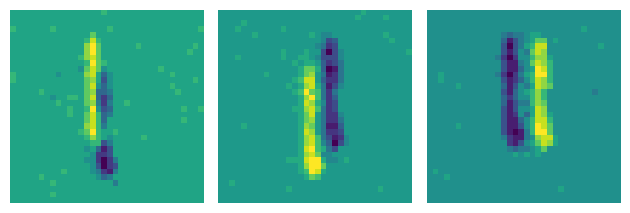

In [48]:
# frame representation
sensor_size = tonic.datasets.NMNIST.sensor_size
frame_transform = transforms.Compose([
    tonic.transforms.ToFrame(sensor_size=sensor_size, n_time_bins=3),
    lambda x: np.diff(x, axis=1).squeeze(axis=1) # do the difference operation here instead of later
])
events, target = dataset[1000]
x,y = dataset[999]
target = np.array([target, y])
frames = np.array([frame_transform(events), frame_transform(x)])
print("Shape of frames:", frames.shape)
print("Target:", target)

fig, axes = plt.subplots(1, len(frames[0]))
for axis, frame in zip(axes, frames[0]):
    # axis.imshow(frame[1] - frame[0])
    axis.imshow(frame)
    axis.axis("off")
plt.tight_layout()
plt.show()

Try to put that into dense net

In [49]:
frames.shape

(2, 3, 34, 34)